# Task 2 – Unsupervised domain adaptation (PACS, Sketch target)
Runtime → **T4 GPU**. Results and the split file are written **directly to Drive** (symlinks), so a disconnect does not lose finished runs. Task 3 reads them from there.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Upload pa1_code.zip to the root of "My Drive" first.
!rm -rf /content/pa1 && unzip -q -o /content/drive/MyDrive/pa1_code.zip -d /content/
DRIVE = "/content/drive/MyDrive/PA1_v2"      # all new results go here (separate from old runs)
!mkdir -p {DRIVE}
# results/ and the shared split folder live on Drive
!mkdir -p {DRIVE}/task2_results {DRIVE}/shared_splits
!rm -rf /content/pa1/task2/results /content/pa1/shared/splits
!ln -s {DRIVE}/task2_results /content/pa1/task2/results
!ln -s {DRIVE}/shared_splits /content/pa1/shared/splits
%cd /content/pa1/task2

Mounted at /content/drive
/content/pa1/task2


In [2]:
import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

CUDA: True Tesla T4


## 1. PACS (same GitHub copy as Task 3, original JPEGs, counts verified)

In [3]:
!python ../shared/download_pacs.py --out /content/pacs_data

Cloning https://github.com/MachineLearning2020/Homework3-PACS.git ...
PACS moved to /content/pacs_data
  [OK ] photo         total= 1670 per class=[189, 202, 182, 186, 199, 280, 432]
  [OK ] art_painting  total= 2048 per class=[379, 255, 285, 184, 201, 295, 449]
  [OK ] cartoon       total= 2344 per class=[389, 457, 346, 135, 324, 288, 405]
  [OK ] sketch        total= 3929 per class=[772, 740, 753, 608, 816, 80, 160]
All 4 domains x 7 classes verified (9,991 images).


## 2. Train the four methods (source-val model selection only)
The first run builds `shared/splits/pacs_sketch_seed6304.json`.

In [4]:
!python train.py --config configs/source_only.yaml

[source_only] device=cuda
[splits] built from /content/pacs_data -> /content/pa1/shared/splits/pacs_sketch_seed6304.json (source fingerprint 718aa257dbf7)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 165MB/s]
[source_only] epoch 0: mean source-val macro-F1=0.8980 {'photo': 0.956, 'art_painting': 0.844, 'cartoon': 0.893} | cls_loss=0.4921 feat_norm_src=49.6052 loss=0.4921
[source_only] epoch 1: mean source-val macro-F1=0.9227 {'photo': 0.945, 'art_painting': 0.883, 'cartoon': 0.94} | cls_loss=0.2032 feat_norm_src=56.6583 loss=0.2032
[source_only] epoch 2: mean source-val macro-F1=0.9210 {'photo': 0.948, 'art_painting': 0.884, 'cartoon': 0.931} | cls_loss=0.1456 feat_norm_src=58.6185 loss=0.1456
[source_only] epoch 3: mean source-val macro-F1=0.9206 {'photo': 0.966, 'art_painting': 0.872, 'cartoon': 0.924} | cls_loss=0.1181 feat_norm_src=62.4467 loss=0.1181
[source_only]

In [5]:
!python train.py --config configs/dan.yaml

[dan] device=cuda
[dan] epoch 0: mean source-val macro-F1=0.9135 {'photo': 0.952, 'art_painting': 0.855, 'cartoon': 0.933} | cls_loss=0.4933 feat_norm_src=44.4150 loss=0.5601 mmd=0.0668
[dan] epoch 1: mean source-val macro-F1=0.9251 {'photo': 0.978, 'art_painting': 0.878, 'cartoon': 0.92} | cls_loss=0.2015 feat_norm_src=48.9442 loss=0.2249 mmd=0.0235
[dan] epoch 2: mean source-val macro-F1=0.9006 {'photo': 0.934, 'art_painting': 0.88, 'cartoon': 0.887} | cls_loss=0.1460 feat_norm_src=48.4782 loss=0.1689 mmd=0.0229
[dan] epoch 3: mean source-val macro-F1=0.9322 {'photo': 0.963, 'art_painting': 0.877, 'cartoon': 0.956} | cls_loss=0.1326 feat_norm_src=46.3031 loss=0.1525 mmd=0.0199
[dan] epoch 4: mean source-val macro-F1=0.9435 {'photo': 0.958, 'art_painting': 0.93, 'cartoon': 0.943} | cls_loss=0.0771 feat_norm_src=49.6078 loss=0.0997 mmd=0.0226
[dan] epoch 5: mean source-val macro-F1=0.9241 {'photo': 0.951, 'art_painting': 0.884, 'cartoon': 0.938} | cls_loss=0.0692 feat_norm_src=49.5433 

In [6]:
!python train.py --config configs/dann.yaml

[dann] device=cuda
[dann] epoch 0: mean source-val macro-F1=0.0372 {'photo': 0.033, 'art_painting': 0.032, 'cartoon': 0.047} | alpha=0.0826 cls_loss=3.3597 disc_acc=0.6270 domain_loss=21.9508 feat_norm_src=336.2639 loss=25.3106
[dann] epoch 1: mean source-val macro-F1=0.1071 {'photo': 0.09, 'art_painting': 0.115, 'cartoon': 0.116} | alpha=0.2441 cls_loss=1.9343 disc_acc=0.4821 domain_loss=0.9457 feat_norm_src=245.5692 loss=2.8801
[dann] epoch 2: mean source-val macro-F1=0.2566 {'photo': 0.337, 'art_painting': 0.179, 'cartoon': 0.254} | alpha=0.3930 cls_loss=1.7386 disc_acc=0.5000 domain_loss=0.7392 feat_norm_src=166.7623 loss=2.4778
[dann] DIVERGED at epoch 3, step 929: loss=1.55e+03 {'cls_loss': 577.607666015625, 'domain_loss': 968.5912475585938, 'disc_acc': 0.5, 'alpha': 0.5794809651333237, 'src_acc': 0.1666666716337204, 'feat_norm_src': 184505.875, 'feat_norm_tgt': 279848.25}
[dann] epoch 3: mean source-val macro-F1=0.0362 {'photo': 0.041, 'art_painting': 0.036, 'cartoon': 0.031} | 

In [7]:
!python train.py --config configs/cdan.yaml

[cdan] device=cuda
[cdan] DIVERGED at epoch 0, step 200: loss=1.38e+03 {'cls_loss': 23.027053833007812, 'domain_loss': 1358.7850341796875, 'disc_acc': 0.3125, 'alpha': 0.14149436476466315, 'src_acc': 0.3333333432674408, 'tgt_top_class_share': 1.0, 'feat_norm_src': 2260.72998046875, 'feat_norm_tgt': 57267.4375}
[cdan] epoch 0: mean source-val macro-F1=0.2114 {'photo': 0.328, 'art_painting': 0.167, 'cartoon': 0.139} | alpha=0.0706 cls_loss=0.8901 disc_acc=0.7583 domain_loss=11.5331 feat_norm_src=62.3914 loss=12.4231
[cdan] stopping: training diverged (best checkpoint kept, epoch 0).
[cdan] done. best epoch 0, mean source-val macro-F1 0.2114 -> ./results/checkpoints/cdan.pt


## 3. Only if DANN / CDAN diverged: supplementary stabilised run
The prescribed run stays the main result; the stabilised run is an extra, clearly labelled row.

In [9]:
import torch, subprocess
for m in ["dann", "cdan"]:
    ck = torch.load(f"results/checkpoints/{m}.pt", map_location="cpu", weights_only=False)
    print(m, "diverged:", ck["diverged"] is not None, ck["diverged"] and {k: ck["diverged"][k] for k in ("epoch", "step", "loss")})
    if ck["diverged"] is not None:
        subprocess.run(["python", "train.py", "--config", f"configs/{m}_stabilized.yaml"], check=True)

dann diverged: True {'epoch': 3, 'step': 929, 'loss': 1546.198974609375}
cdan diverged: True {'epoch': 0, 'step': 200, 'loss': 1381.8121337890625}


## 4. Controlled study: λ_MMD ∈ {0.1, 1, 10} (λ = 1 reuses the main DAN checkpoint)

In [10]:
!python run_controlled_study.py --study dan

--- lambda_mmd=0.1: training
[dan_lambda_mmd0.1] device=cuda
[dan_lambda_mmd0.1] epoch 0: mean source-val macro-F1=0.8952 {'photo': 0.943, 'art_painting': 0.827, 'cartoon': 0.915} | cls_loss=0.4853 feat_norm_src=47.9465 loss=0.5035 mmd=0.1821
[dan_lambda_mmd0.1] epoch 1: mean source-val macro-F1=0.9227 {'photo': 0.967, 'art_painting': 0.874, 'cartoon': 0.927} | cls_loss=0.2058 feat_norm_src=52.8164 loss=0.2151 mmd=0.0934
[dan_lambda_mmd0.1] epoch 2: mean source-val macro-F1=0.9312 {'photo': 0.95, 'art_painting': 0.901, 'cartoon': 0.942} | cls_loss=0.1420 feat_norm_src=53.6673 loss=0.1498 mmd=0.0780
[dan_lambda_mmd0.1] epoch 3: mean source-val macro-F1=0.9288 {'photo': 0.95, 'art_painting': 0.905, 'cartoon': 0.931} | cls_loss=0.0957 feat_norm_src=55.9999 loss=0.1022 mmd=0.0651
[dan_lambda_mmd0.1] epoch 4: mean source-val macro-F1=0.9212 {'photo': 0.955, 'art_painting': 0.875, 'cartoon': 0.934} | cls_loss=0.0911 feat_norm_src=57.9982 loss=0.0975 mmd=0.0644
[dan_lambda_mmd0.1] epoch 5: me

## 5. Final evaluation – first use of Sketch labels

In [11]:
!python evaluate_final.py --controlled_study dan

Evaluating source_only ...
Evaluating dan ...
Evaluating dann ...
Evaluating cdan ...
Evaluating dann_stabilized ...
Evaluating cdan_stabilized ...

Comparison table:
{'method': 'source_only', 'photo_val_acc': 0.964, 'art_painting_val_acc': 0.9415, 'cartoon_val_acc': 0.9424, 'photo_val_f1': 0.9581, 'art_painting_val_f1': 0.9421, 'cartoon_val_f1': 0.9466, 'mean_source_acc': 0.9493, 'mean_source_f1': 0.9489, 'target_acc': 0.5729, 'target_f1': 0.584, 'target_acc_change_vs_source_only': 0.0, 'domain_separability': 0.9973, 'best_epoch': 6, 'diverged': False}
{'method': 'dan', 'photo_val_acc': 0.964, 'art_painting_val_acc': 0.9293, 'cartoon_val_acc': 0.9382, 'photo_val_f1': 0.9577, 'art_painting_val_f1': 0.9296, 'cartoon_val_f1': 0.9431, 'mean_source_acc': 0.9438, 'mean_source_f1': 0.9435, 'target_acc': 0.6869, 'target_f1': 0.6331, 'target_acc_change_vs_source_only': 0.114, 'domain_separability': 0.8695, 'best_epoch': 4, 'diverged': False}
{'method': 'dann', 'photo_val_acc': 0.4505, 'art_pai

Accuracies / F1 / separability in %.

| method | photo_val_acc | art_painting_val_acc | cartoon_val_acc | mean_source_acc | mean_source_f1 | target_acc | target_f1 | target_acc_change_vs_source_only | domain_separability | diverged |
|---|---|---|---|---|---|---|---|---|---|---|
| source_only | 96.40 | 94.15 | 94.24 | 94.93 | 94.89 | 57.29 | 58.40 | 0.00 | 99.73 | False |
| dan | 96.40 | 92.93 | 93.82 | 94.38 | 94.35 | 68.69 | 63.31 | 11.40 | 86.95 | False |
| dann | 45.05 | 22.20 | 32.41 | 33.22 | 25.66 | 30.92 | 20.78 | -26.37 | 97.53 | True |
| cdan | 43.54 | 26.34 | 22.60 | 30.83 | 21.14 | 2.04 | 0.57 | -55.26 | 99.73 | True |
| dann_stabilized | 88.89 | 73.66 | 72.28 | 78.28 | 77.25 | 15.47 | 3.83 | -41.82 | 99.86 | True |
| cdan_stabilized | 96.70 | 90.00 | 91.26 | 92.65 | 92.85 | 43.17 | 48.56 | -14.13 | 98.63 | False |

results/plots/controlled_study_dan.png


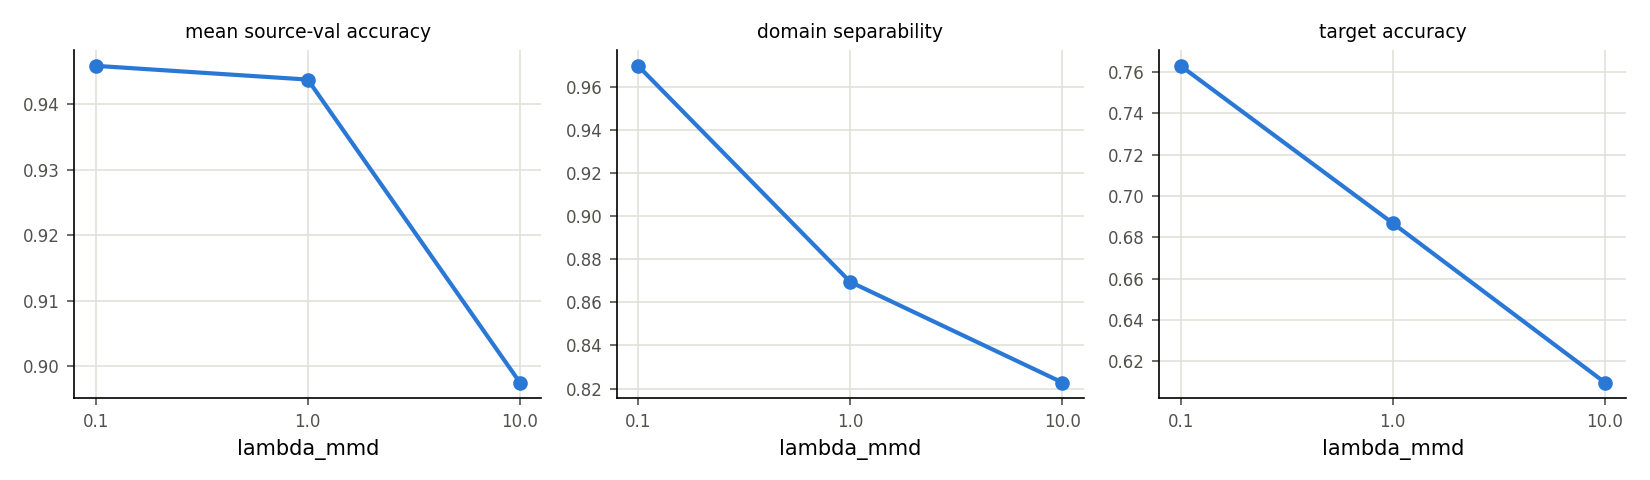

results/plots/controlled_study_dan_curves.png


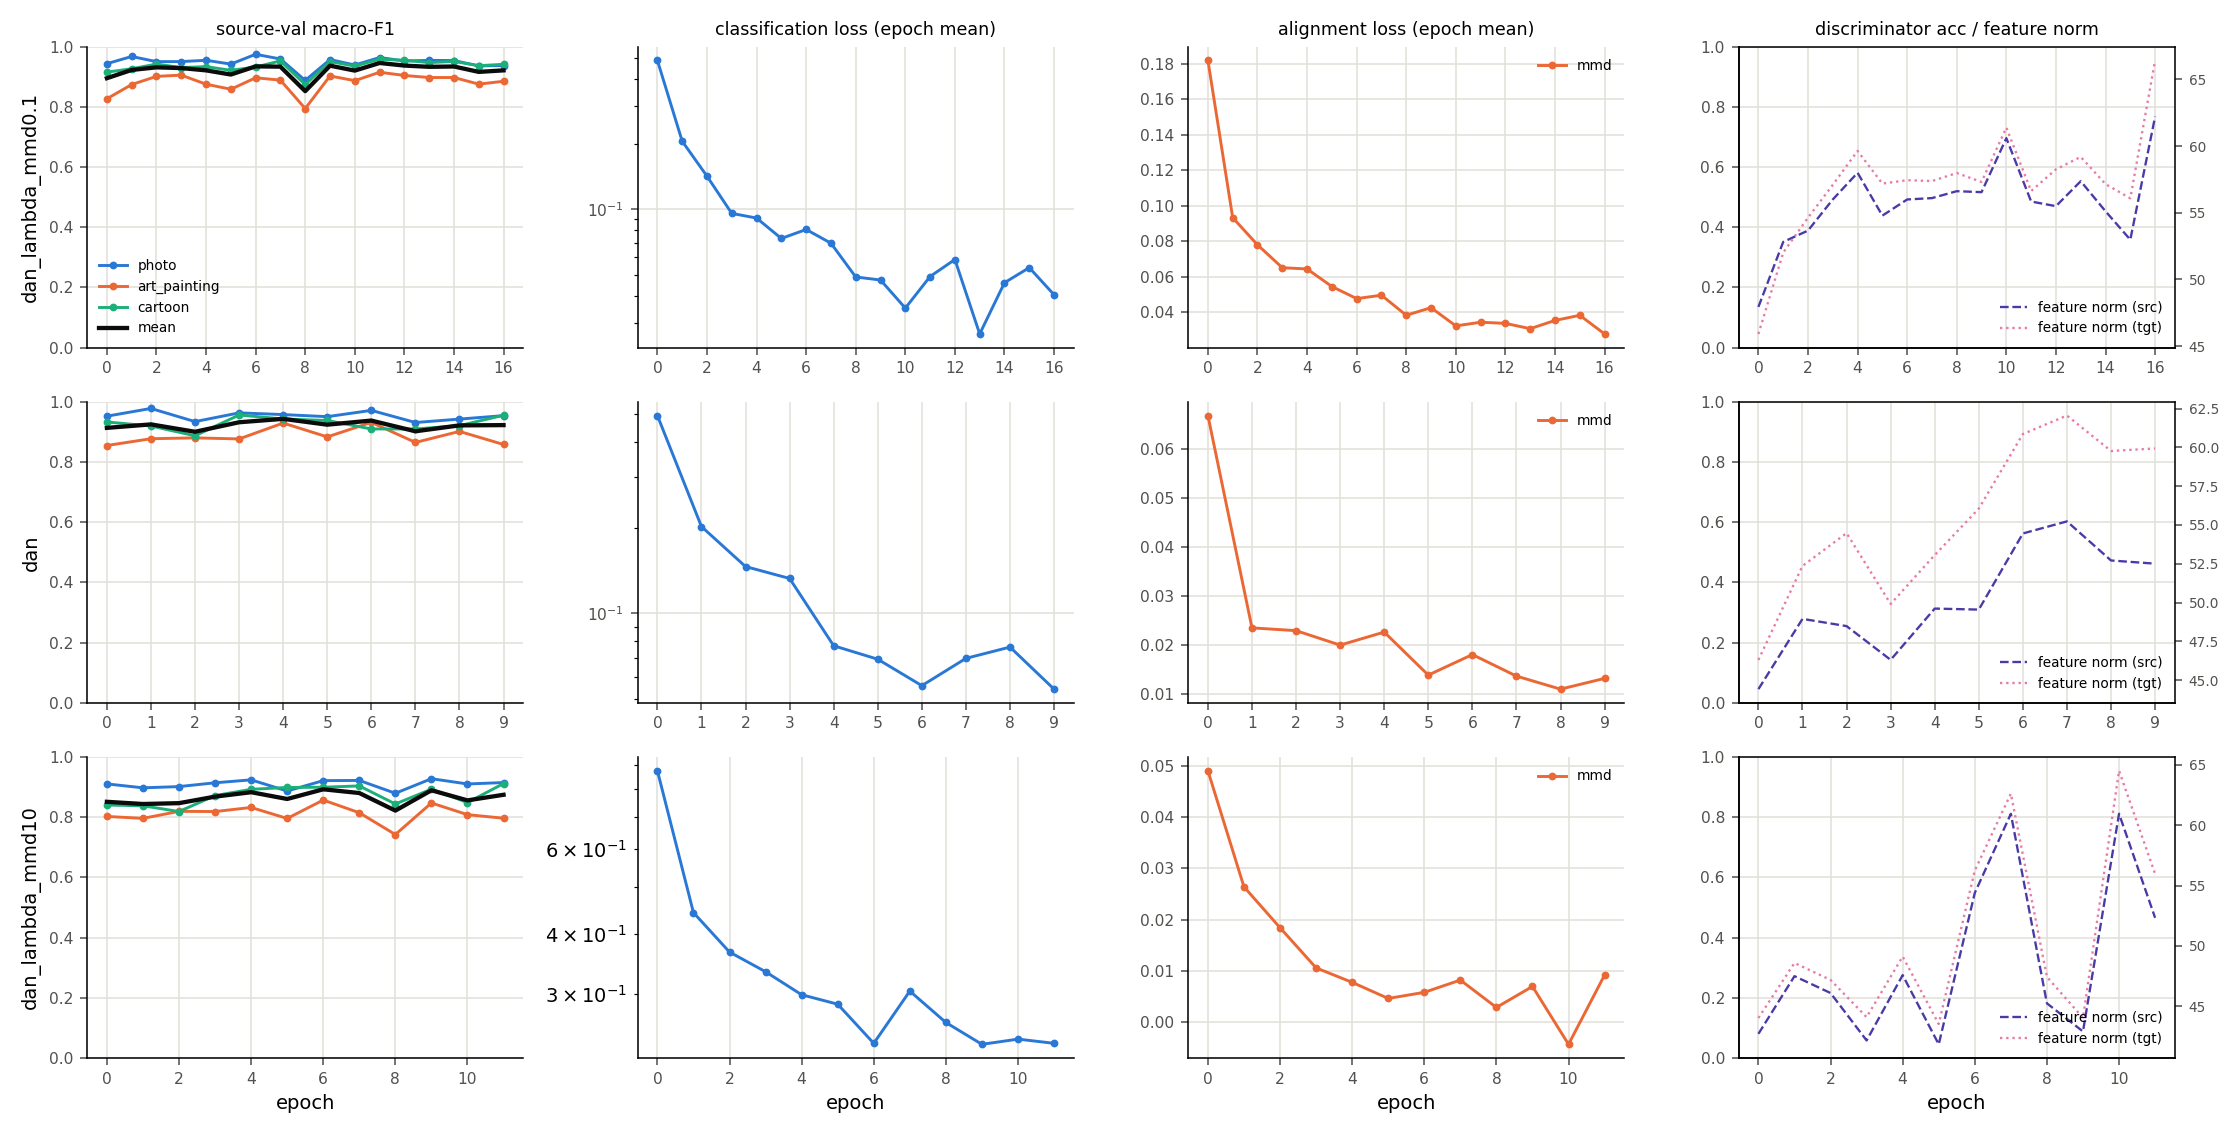

results/plots/per_class_delta.png


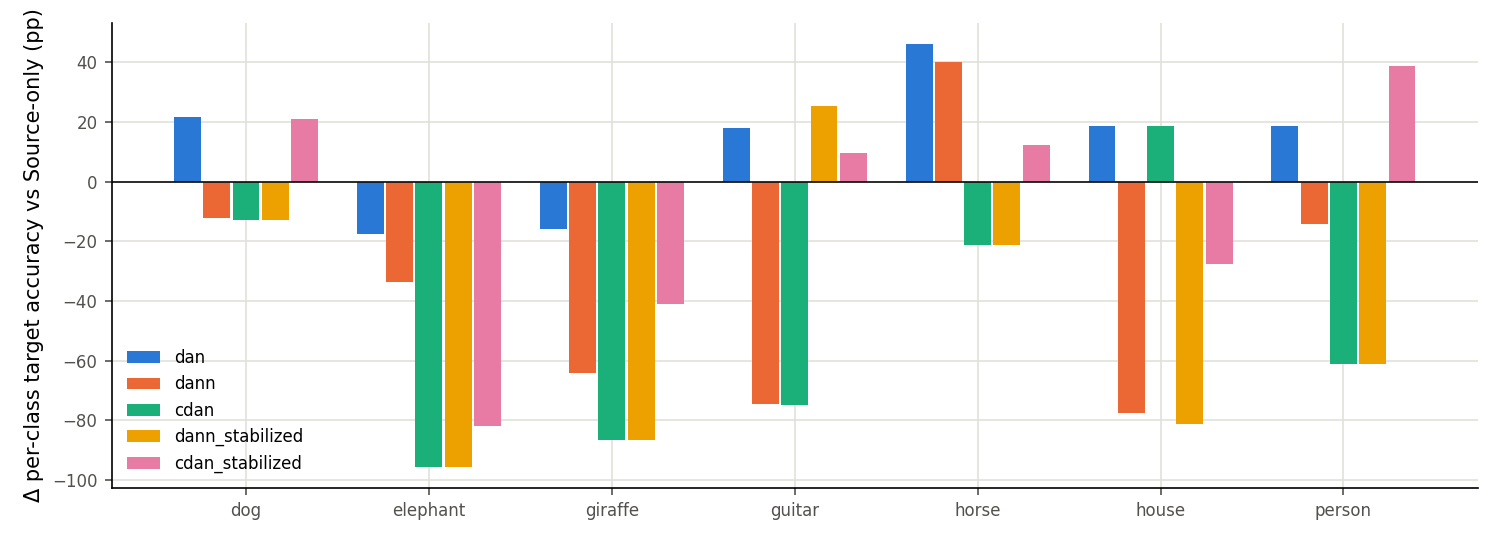

results/plots/target_confusions.png


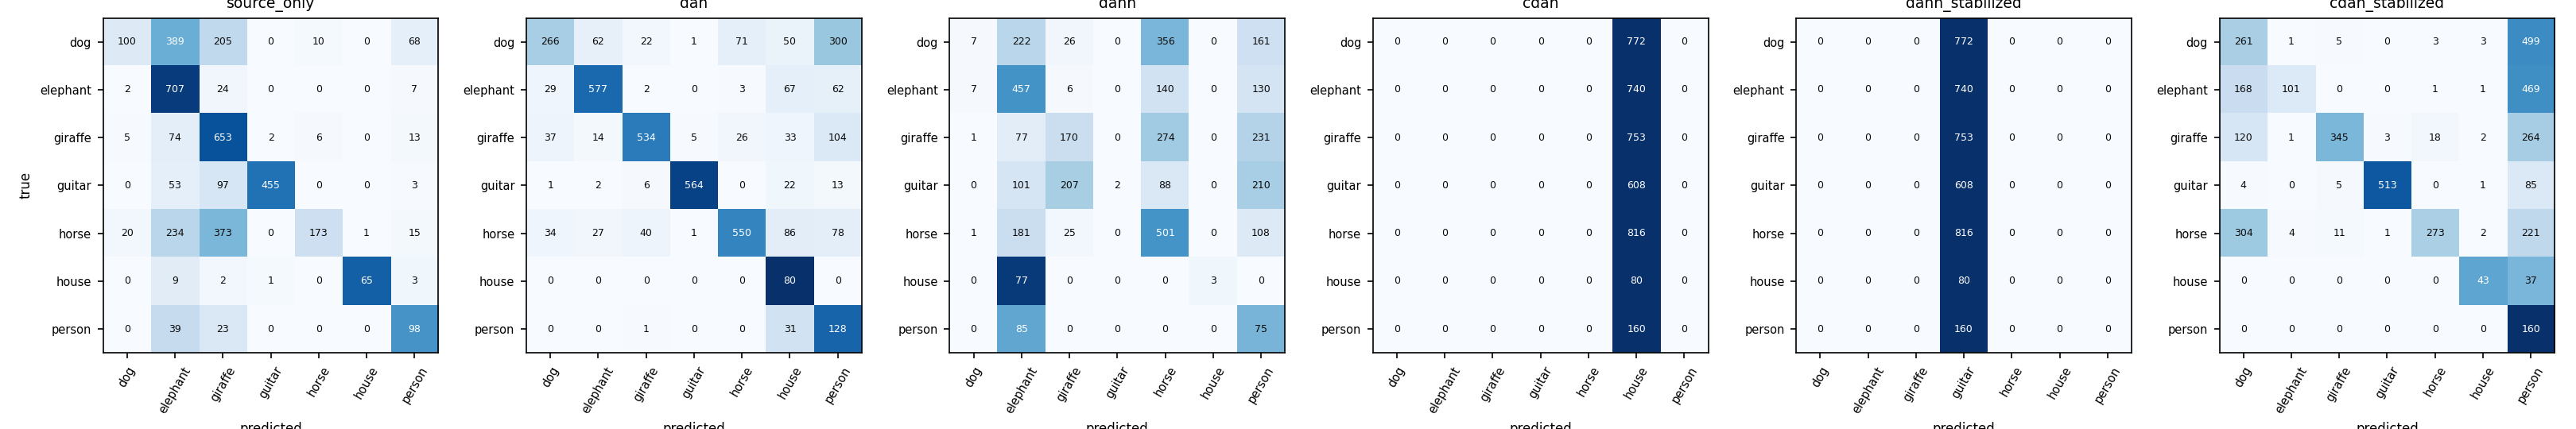

results/plots/training_curves.png


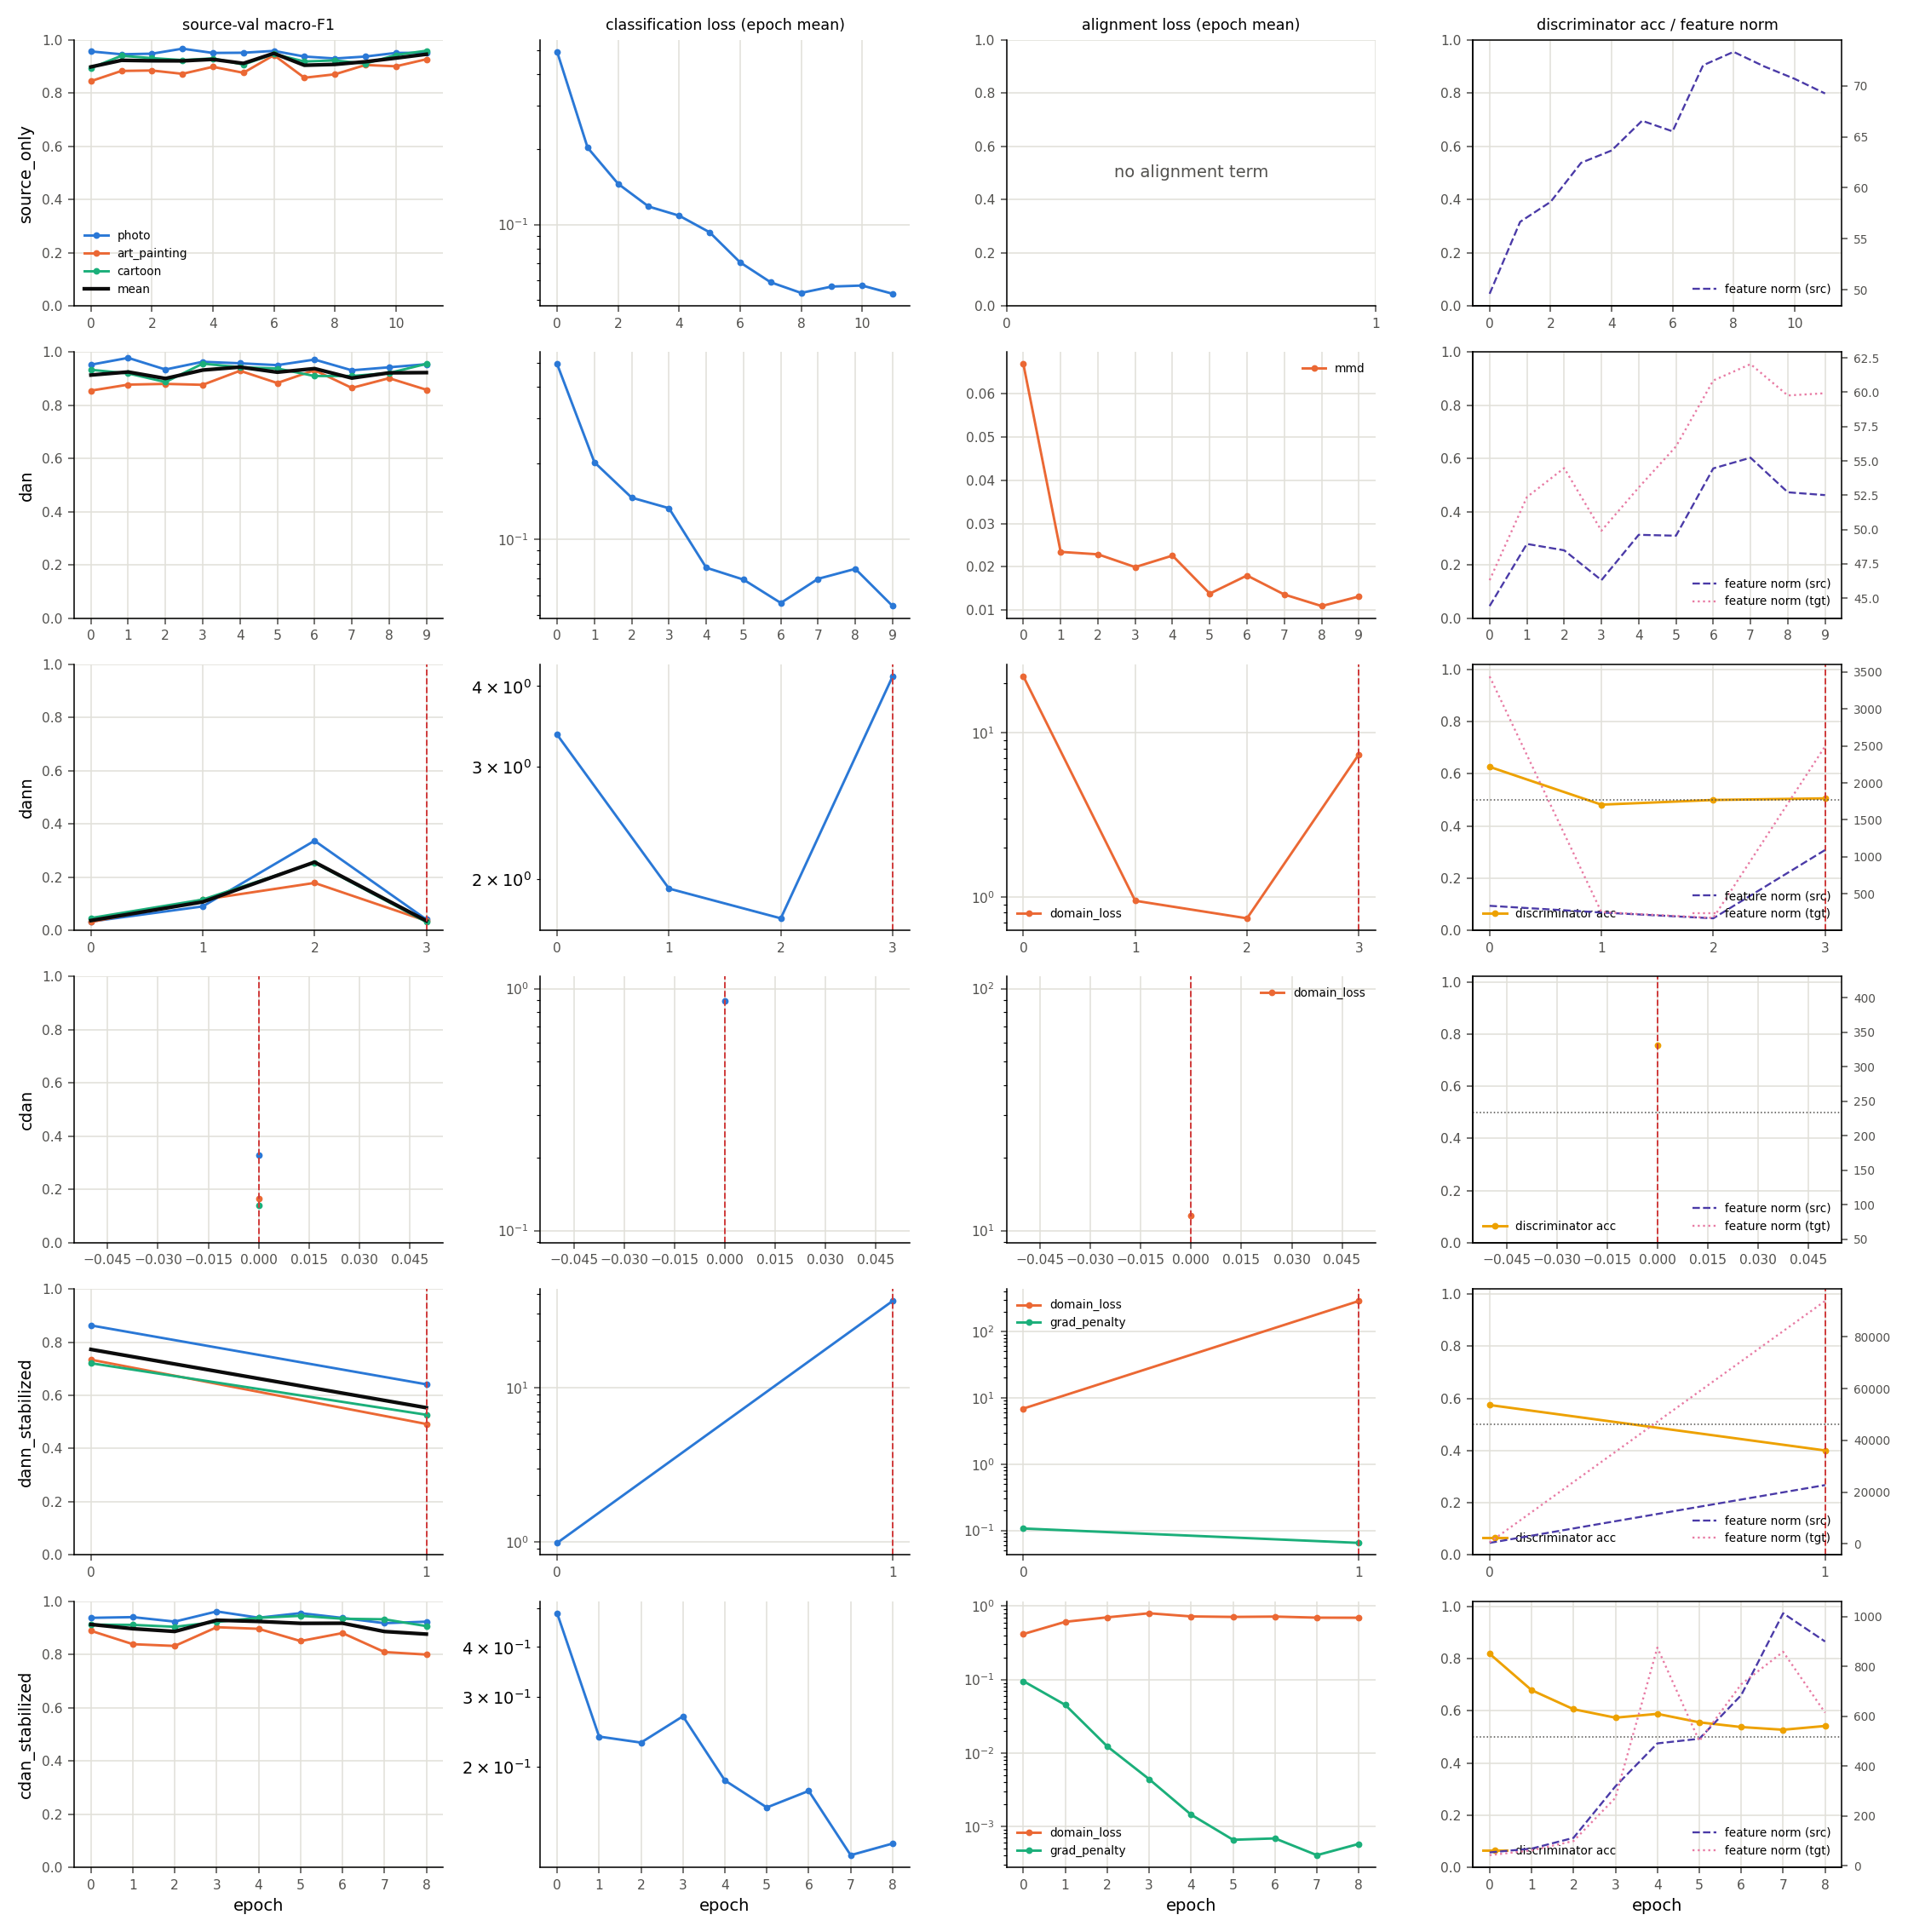

In [12]:
import glob
from IPython.display import Image, display
print(open('results/comparison_table.md').read())
for f in sorted(glob.glob('results/plots/*.png')):
    print(f); display(Image(f, width=1100))

Everything is already on Drive in `PA1_v2/task2_results` and `PA1_v2/shared_splits` (needed by Task 3).